**objective**

Based on customer's Item Description and Purchase history, can I create customer segments that infers their MBTI type?

- Product Groups
- Shopping Needs
- Customer Profile Segments ( What are they like for e.g. Can you infer their MBTI from this? )

**Domain Background**

As Of **2026** the popular Classification Methods For Multi-labels with possible overlapping patterns

- Hyperplane
- K-NN 
- SOM

Dimensional Reduction methods

- PCA
- t-SNE
- UMAP / Manifold Learning 

**Notebook Configuration**

- [Pre-trained models used in this notebook](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
- Dataset used is based on [Ecommerce Dataset](https://www.kaggle.com/datasets/carrie1/ecommerce-data) and its respective EDA notebooks can be viewed [here](https://www.kaggle.com/code/farzadnekouei/customer-segmentation-recommendation-system). 

---

**References**

- [K-Means Vs Hierarchical Clustering](https://www.geeksforgeeks.org/machine-learning/difference-between-k-means-and-hierarchical-clustering/)
- [Introducing self-organized maps (SOM) as a visualization tool for materials research and education](https://www.sciencedirect.com/science/article/pii/S2590048X19300202)
- [Weighted K-Means](https://www.researchgate.net/profile/Nittaya-Kerdprasop/publication/225127898_Weighted_K-Means_for_Density-Biased_Clustering/links/0c96053191e3985477000000/Weighted-K-Means-for-Density-Biased-Clustering.pdf)
- [Matrix Factorisation](https://www.r-bloggers.com/2017/10/segmenting-customers-by-their-purchase-histories-using-non-negative-matrix-factorization/#:~:text=Challenges,not%20explaining%20the%20data%20well)
- [Matrix Factorisation - How it works](https://datajobs.com/data-science-repo/Recommender-Systems-[Netflix].pdf)

---



In [ ]:
!pip install -U sentence-transformers

In [ ]:
from pathlib import Path 
import pandas as pd 

INPUT_PATH = Path('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv')
COLS = [
    'InvoiceNo', 
    'StockCode', 
    'Description', 
    'Quantity', 
    'InvoiceDate',
    'UnitPrice',
    'CustomerID',
    'Country'
]

assert INPUT_PATH.exists() and INPUT_PATH.is_file() 

df = pd.read_csv(INPUT_PATH, encoding='latin1')

In [4]:
from sentence_transformers import SentenceTransformer 

MODEL_ID = "all-MiniLM-L6-v2"
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Data Preprocessing

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
SAMPLE_SIZE = 100
X = model.encode(df.head(SAMPLE_SIZE)['Description'].values)

# Estimating the number of groups given the Item Description

POpular methods implemented with K-Means:

- Silhouette Score 
- Elbow Method
- Bayesian Information Criterion (BIC)
- Density-Based Methods e.g. DBScan

In this case, trial with Silhuoette

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
K = range(2,10)

for k in K:
    labels = KMeans(n_clusters=k).fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}\tscore={score}")
    scores.append(score)

best_k = K[scores.index(max(scores))]
print(best_k)

k=2	score=0.038592562079429626
k=3	score=0.07296735048294067
k=4	score=0.08728457242250443
k=5	score=0.0955428034067154
k=6	score=0.12910713255405426
k=7	score=0.14862366020679474
k=8	score=0.15277442336082458
k=9	score=0.1634073704481125
9


In [27]:
simi_matrix = model.similarity(X, X)

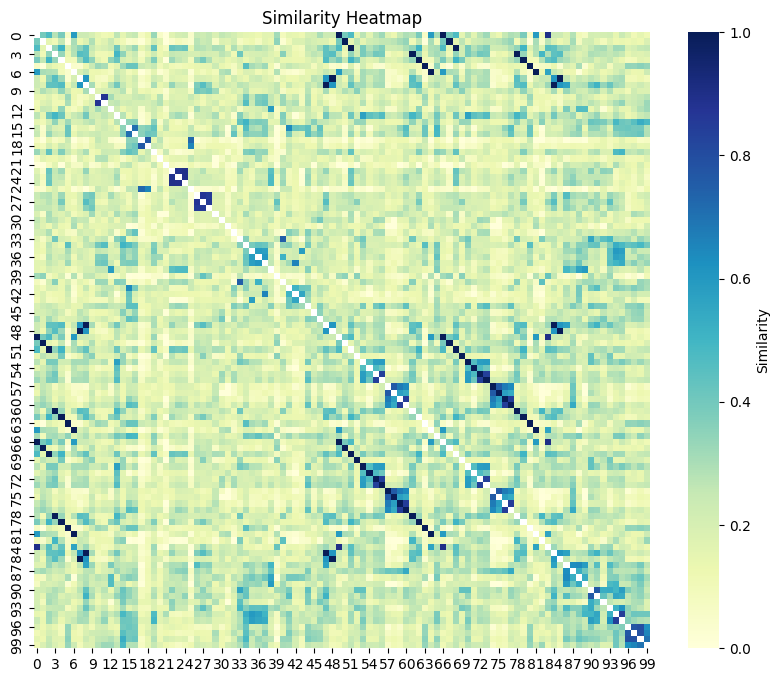

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

matrix = simi_matrix.numpy().copy()
mask = np.eye(matrix.shape[0], dtype=bool)

plt.figure(figsize=(10,8))
sns.heatmap(matrix, mask=mask, vmin=0, vmax=1, cbar_kws={'label': 'Similarity'},  cmap="YlGnBu", square=True)


plt.title("Similarity Heatmap")
plt.show()


In [16]:
df.groupby(["CustomerID", "InvoiceNo"]).agg({
    "Quantity": ["count", "sum", "mean"],
    "UnitPrice": ["count", "sum", "mean"]
}).round(2)

Quantity                  UnitPrice             
                        count    sum      mean     count    sum  mean
CustomerID InvoiceNo                                                 
12346.0    541431           1  74215  74215.00         1   1.04  1.04
           C541433          1 -74215 -74215.00         1   1.04  1.04
12347.0    537626          31    319     10.29        31  89.59  2.89
           542237          29    315     10.86        29  73.17  2.52
           549222          24    483     20.12        24  62.29  2.60
...                       ...    ...       ...       ...    ...   ...
18283.0    579673          52    134      2.58        52  85.08  1.64
           580872          50    142      2.84        50  65.38  1.31
18287.0    554065          29    488     16.83        29  56.92  1.96
           570715          38    990     26.05        38  45.70  1.20
           573167           3    108     36.00         3   1.93  0.64

[22190 rows x 6 columns]